# Processing data from the C++ program

In [1]:
using Plots
using JuliVirBootstrap
import Polynomials: fit
using Symbolics
using JLD2
import DataFrames: DataFrame
import GLM: lm, @formula, coef

res_dir = "/Users/Paul/Documents/Recherche/projet_these/code/transfer_matrices/TransferMatricesCpp/FK_loops/results";
cd(res_dir)

All computations have been performed at $\lambda = 0.5$ where $\lambda$ is related to our usual parameters via
$$
\beta^2 = \frac{4\pi}{\lambda}
$$

In [2]:
λ = 0.5
β = sqrt(4λ/π)

0.7978845608028654

## Checking the central charge

We start by checking the central charge, which we get as

$$ -\frac1L\log \Lambda_0(L) = f_0^\infty - \frac{\pi c}{6L^2} $$

### From the two-point function

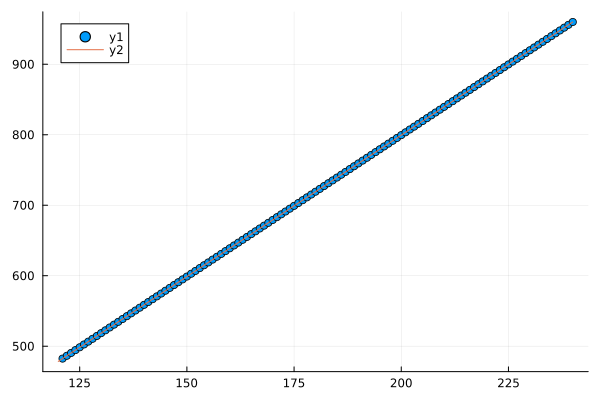

-0.24033248352026976


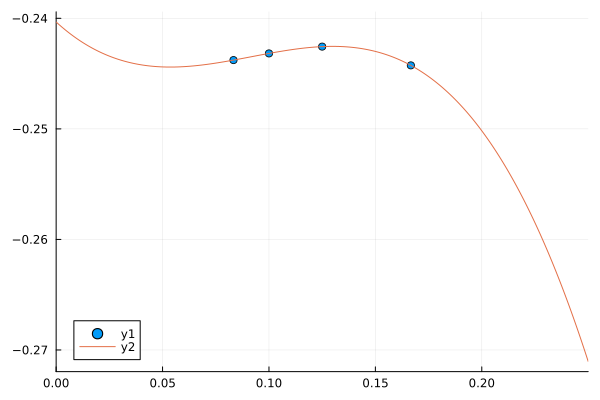

In [19]:
C10s = load("two_point_no_defects_diagonal.jld2", "data")
Ms(L) = sort([k for k in keys(C10s[L])])
C10Ls(L) = [C10s[L][M] for M in Ms(L)];

# linear fit
data(L) = DataFrame(M = Ms(L), logC10 = Float64.(log.(C10Ls(L))))
model(L) = lm(@formula(logC10 ~ M), data(L))

L=6
mesh = 20*L:0.1:40*L
plt = scatter(Ms(L), log.(C10Ls(L)))
linearfit(L) = coef(model(L))
plot!(plt, mesh, linearfit(L)[1] .+ linearfit(L)[2].*mesh)
display(plt)

logΛ10(L) = linearfit(L)[2];

# using the linear fit we almost perfectly match the eigenvalues of the transfer matrix,
# down to ~1e-7 at worst, using reasonably small cylinders
@variables c1, c2, c3

f10(L) = -logΛ10(L)/L

# get an effective central charge from sizes L, L+1 and L+2
eq(L) = c1 - π*c2/6/(L/sqrt(2))^2 + c3/L^4 - f10(L)
c_eff(L) = Symbolics.solve_for([eq(L), eq(L+2), eq(L+4)], [c1, c2, c3])[2]

Lrange = 6:2:12
c_effs = [c_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p0 = fit(Ls, c_effs)
println(p0(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, c_effs)
plot!(xfine, p0.(xfine), xlims=(0, 0.25))

## Two-point function of the two-leg operator
### From the spectrum

We extract the dimension of the two-leg operator thanks to

$$
-\frac{1}{L} \log(\frac{\Lambda(L)}{\Lambda_0(L)}) = \frac{2\pi\Delta}{L^2} + o(L^{-2}).
$$

where $\Lambda$ is the highest eigenvalue in the sector with two defects.

3.8173977612116134
0.19445070700145176


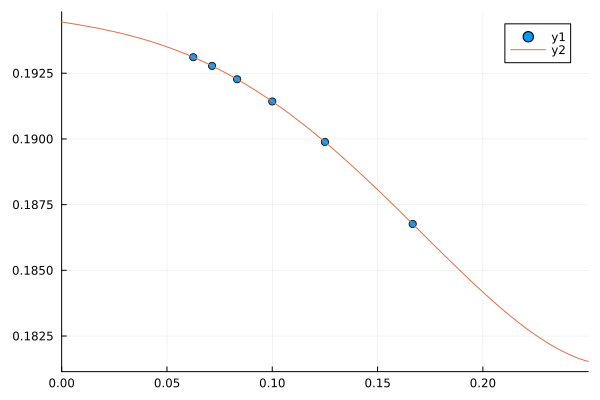

In [23]:
# load the data, below is for λ = 0.5, n = -2cos(4λ)
Λ1s = load("ev_2_defects.jld2", "data")
Λ1(L) = Λ1s[L][1];
println(log(abs(Λ1(6))))
@variables Δ

f1(L) = -log(real(Λ1(L)))/L

# get an effective scaling dimension at size L
eq(L) = f1(L)-f10(L) - π*Δ*2/(L)^2
Δ_eff(L) = Symbolics.value(Symbolics.solve_for(eq(L), Δ))

Lrange = 6:2:16
Δ_effs = [Δ_eff(L) for L in Lrange]
Ls = 1 ./ Lrange

# interpolate the central charges to infinite size
deg = length(Lrange)-1
p1 = fit(Ls, Δ_effs)
println(p1(0))

# Plot to check soundness
xfine = 0:0.001:0.25
scatter(Ls, Δ_effs)
plot!(xfine, p1.(xfine), xlims=(0, 0.25))